# 01 — Baselines

**Spec: §5.** Four baselines, not one. Three are nearly free and they are what
make the final table honest.

| Baseline | Question it answers |
|---|---|
| Majority class | What does zero signal look like? |
| **TF-IDF + LogReg** | **Is a transformer worth it at all?** |
| Off-the-shelf model | Why not just use something that exists? |
| Zero-shot | Is *labelled data* worth it? |

The TF-IDF row is the one that matters. Most portfolio projects skip it
because it is embarrassing — on binary review sentiment it is very strong. If
the fine-tuned transformer later wins by three points, the honest headline is
"three points over a model that trains in twenty seconds on CPU", and that
delta is the justification for the whole project.

> The last two baselines need torch and are run on Kaggle. Everything in this
> notebook runs on CPU in about two minutes.

In [1]:
import sys, json, time
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from datasets import load_dataset
from sklearn.pipeline import make_pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             ConfusionMatrixDisplay)

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO))
from src.normalize import normalize

LABELS = ["négatif", "positif"]
RESULTS = {}

C:\Users\Windownet\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ds = load_dataset("tblard/allocine")

# §1.1 THE CONTRACT: the test split does not exist in this notebook.
ds.pop("test")

sub_idx = np.load(REPO / "data" / "train_subsample_40k.npy")

Xtr_full = [normalize(t) for t in ds["train"]["review"]]
ytr_full = np.array(ds["train"]["label"])
Xtr = [Xtr_full[i] for i in sub_idx]
ytr = ytr_full[sub_idx]

Xva = [normalize(t) for t in ds["validation"]["review"]]
yva = np.array(ds["validation"]["label"])

print(f"train (40k subsample): {len(Xtr):>6,}   balance {dict(Counter(ytr))}")
print(f"train (full)         : {len(Xtr_full):>6,}")
print(f"validation           : {len(Xva):>6,}   balance {dict(Counter(yva))}")

train (40k subsample): 40,000   balance {np.int64(1): 20000, np.int64(0): 20000}
train (full)         : 160,000
validation           : 20,000   balance {np.int64(0): 10204, np.int64(1): 9796}


In [3]:
def evaluate(name, y_true, y_pred, seconds=None, note=""):
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    per = f1_score(y_true, y_pred, average=None)
    RESULTS[name] = {"accuracy": round(float(acc), 4),
                     "macro_f1": round(float(f1m), 4),
                     "f1_negatif": round(float(per[0]), 4),
                     "f1_positif": round(float(per[1]), 4),
                     "train_seconds": None if seconds is None else round(seconds, 1),
                     "note": note}
    print(f"{name}\n  accuracy {acc:.4f} | macro-F1 {f1m:.4f} | "
          f"F1 neg {per[0]:.4f} / pos {per[1]:.4f}"
          + (f" | {seconds:.1f}s" if seconds else ""))
    return acc, f1m

## 5.1 Majority class

Anchors the bottom of the table. Allociné is near-balanced, so accuracy lands
near 0.50 while macro-F1 collapses to ~0.33 — which is exactly why §1.2 makes
macro-F1 primary and treats accuracy as a secondary report.

In [4]:
dummy = DummyClassifier(strategy="most_frequent").fit(Xtr, ytr)
evaluate("majority_class", yva, dummy.predict(Xva))

majority_class
  accuracy 0.5102 | macro-F1 0.3378 | F1 neg 0.6757 / pos 0.0000


(0.5102, 0.3378360482055357)

## 5.2 TF-IDF + Logistic Regression

**The baseline that matters.** Word 1–2 grams, min_df=2, sublinear tf.

Trained on the same 40k subsample the transformer will use, so the comparison
is like-for-like. The full-160k row is included to show what the subsample
costs — that number also tells you whether the §4.3 budget decision was
expensive.

In [5]:
t0 = time.perf_counter()
tfidf_word = make_pipeline(
    TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True),
    LogisticRegression(max_iter=2000, class_weight="balanced"),
).fit(Xtr, ytr)
t_word = time.perf_counter() - t0

evaluate("tfidf_word_40k", yva, tfidf_word.predict(Xva), t_word,
         "word 1-2 grams, 40k subsample")

tfidf_word_40k
  accuracy 0.9238 | macro-F1 0.9238 | F1 neg 0.9249 / pos 0.9227 | 12.4s


(0.92385, 0.9238336529881885)

In [6]:
t0 = time.perf_counter()
tfidf_full = make_pipeline(
    TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True),
    LogisticRegression(max_iter=2000, class_weight="balanced"),
).fit(Xtr_full, ytr_full)
t_full = time.perf_counter() - t0

evaluate("tfidf_word_160k", yva, tfidf_full.predict(Xva), t_full,
         "word 1-2 grams, full train -- shows the cost of the 40k subsample")

tfidf_word_160k
  accuracy 0.9372 | macro-F1 0.9372 | F1 neg 0.9380 / pos 0.9363 | 52.9s


(0.9372, 0.9371887216068517)

In [7]:
# Word + character n-grams. char_wb handles French morphology and
# misspellings well, and review text is full of both.
t0 = time.perf_counter()
tfidf_wc = make_pipeline(
    FeatureUnion([
        ("w", TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)),
        ("c", TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5),
                              min_df=3, sublinear_tf=True)),
    ]),
    LogisticRegression(max_iter=3000, class_weight="balanced"),
).fit(Xtr, ytr)
t_wc = time.perf_counter() - t0

evaluate("tfidf_word_char_40k", yva, tfidf_wc.predict(Xva), t_wc,
         "word 1-2 + char_wb 3-5, 40k subsample")

tfidf_word_char_40k
  accuracy 0.9286 | macro-F1 0.9286 | F1 neg 0.9297 / pos 0.9275 | 55.9s


(0.92865, 0.9286331843724849)

best CPU baseline: tfidf_word_char_40k 



              precision    recall  f1-score   support

     négatif     0.9344    0.9251    0.9297     10204
     positif     0.9228    0.9323    0.9275      9796

    accuracy                         0.9286     20000
   macro avg     0.9286    0.9287    0.9286     20000
weighted avg     0.9287    0.9286    0.9287     20000



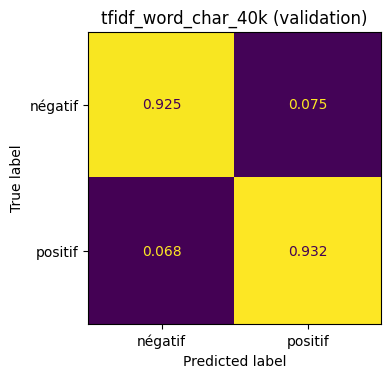

In [8]:
best = max(("tfidf_word_40k", "tfidf_word_char_40k"),
           key=lambda k: RESULTS[k]["macro_f1"])
best_model = tfidf_word if best == "tfidf_word_40k" else tfidf_wc
print("best CPU baseline:", best, "\n")
print(classification_report(yva, best_model.predict(Xva),
                            target_names=LABELS, digits=4))

fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay.from_predictions(
    yva, best_model.predict(Xva), display_labels=LABELS,
    normalize="true", values_format=".3f", colorbar=False, ax=ax)
ax.set_title(f"{best} (validation)")
plt.tight_layout(); plt.show()

### Error asymmetry — the number §10 depends on

The aggregate correction needs TPR and FPR. Measuring them here, on a model
that already exists, shows how much bias naive counting would carry *even with
a decent classifier* — and gives a preview of the §10 result before any
transformer is trained.

In [9]:
from src.estimate import confusion_rates, acc_prevalence, classify_and_count

pred_va = best_model.predict(Xva)
tpr, fpr = confusion_rates(yva, pred_va, positive=1)
print(f"TPR {tpr:.4f}   FPR {fpr:.4f}   (asymmetry {abs(tpr - (1-fpr)):.4f})")

print("\nWhat naive Classify-and-Count would report at various true rates:")
print(f"{'true':>6} {'CC':>8} {'ACC':>8} {'CC err':>8}")
for p in (0.1, 0.3, 0.5, 0.7, 0.9):
    cc = tpr * p + fpr * (1 - p)        # expected CC output
    print(f"{p:>6.2f} {cc:>8.3f} {acc_prevalence(cc, tpr, fpr):>8.3f} "
          f"{cc - p:>+8.3f}")

RESULTS[best]["tpr"] = round(float(tpr), 4)
RESULTS[best]["fpr"] = round(float(fpr), 4)

TPR 0.9323   FPR 0.0749   (asymmetry 0.0072)

What naive Classify-and-Count would report at various true rates:
  true       CC      ACC   CC err
  0.10    0.161    0.100   +0.061
  0.30    0.332    0.300   +0.032
  0.50    0.504    0.500   +0.004
  0.70    0.675    0.700   -0.025
  0.90    0.847    0.900   -0.053


## 5.3 / 5.4 — Off-the-shelf and zero-shot

Both need torch and are run on Kaggle.

* **Off-the-shelf:** `nlptown/bert-base-multilingual-uncased-sentiment`
  (5-star, multilingual product reviews — collapse 1–2★→négatif, 4–5★→positif).
  Its training domain is *product* reviews, closer to the end use than movie
  reviews, so it is a genuinely informative comparison.
* **Zero-shot:** `MoritzLaurer/mDeBERTa-v3-base-mnli-xnli`, candidate labels
  `["positif", "négatif"]`. Try two or three hypothesis templates and report
  which won — zero-shot swings several points on phrasing.

> ⚠️ **Do not benchmark against a model trained on Allociné** (several exist on
> the Hub, including `tblard/tf-allocine`). They have seen this test set; the
> comparison is meaningless. Mention the exclusion and why — the catch itself
> is worth a sentence.

In [10]:
out = REPO / "data" / "results_baselines.json"
out.write_text(json.dumps(RESULTS, indent=2, ensure_ascii=False) + "\n",
               encoding="utf-8")

print(f"{'baseline':<24} {'acc':>7} {'macroF1':>8} {'train s':>8}")
print("-" * 50)
for k, v in sorted(RESULTS.items(), key=lambda kv: kv[1]["macro_f1"]):
    print(f"{k:<24} {v['accuracy']:>7.4f} {v['macro_f1']:>8.4f} "
          f"{str(v['train_seconds'] or '-'):>8}")
print(f"\nwrote {out}")

baseline                     acc  macroF1  train s
--------------------------------------------------
majority_class            0.5102   0.3378        -
tfidf_word_40k            0.9238   0.9238     12.4
tfidf_word_char_40k       0.9286   0.9286     55.9
tfidf_word_160k           0.9372   0.9372     52.9

wrote D:\NLP Analyse de sentiment\data\results_baselines.json


## The bar the transformer has to clear

Whatever CamemBERT scores in notebook 02, subtract the best number above.
*That* difference — not the raw accuracy — is what the fine-tuning bought, and
it is the number that belongs in the README headline.

If the gap is small, say so. A three-point gain over a twenty-second CPU model
is a real and reportable result; pretending the 95% figure stands alone is not.